In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# Specify the full path to your CSV file, including the file name
file_path = r'C:\Users\Shubhan\Downloads\country_wise_latest.csv'  # Ensure this path is correct

try:
    # Use pandas to read the CSV file
    df = pd.read_csv(file_path)
    
    # Display the first few rows of the DataFrame
    print(df.head(50))
except PermissionError:
    print("Permission denied: Please check if the file is open in another program or if you have the necessary permissions.")
except FileNotFoundError:
    print("File not found: Please check if the file path is correct and the file exists.")
except Exception as e:
    print(f"An error occurred: {e}")

              Country/Region  Confirmed  Deaths  Recovered  Active  New cases  \
0                Afghanistan      36263    1269      25198    9796        106   
1                    Albania       4880     144       2745    1991        117   
2                    Algeria      27973    1163      18837    7973        616   
3                    Andorra        907      52        803      52         10   
4                     Angola        950      41        242     667         18   
5        Antigua and Barbuda         86       3         65      18          4   
6                  Argentina     167416    3059      72575   91782       4890   
7                    Armenia      37390     711      26665   10014         73   
8                  Australia      15303     167       9311    5825        368   
9                    Austria      20558     713      18246    1599         86   
10                Azerbaijan      30446     423      23242    6781        396   
11                   Bahamas

DataFrame Shape: (187, 15)
DataFrame Columns: Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered / 100 Cases', 'Deaths / 100 Recovered',
       'Confirmed last week', '1 week change', '1 week % increase',
       'WHO Region'],
      dtype='object')
Data Types:
 Country/Region             object
Confirmed                   int64
Deaths                      int64
Recovered                   int64
Active                      int64
New cases                   int64
New deaths                  int64
New recovered               int64
Deaths / 100 Cases        float64
Recovered / 100 Cases     float64
Deaths / 100 Recovered    float64
Confirmed last week         int64
1 week change               int64
1 week % increase         float64
WHO Region                 object
dtype: object
Summary Statistics:
           Confirmed         Deaths     Recovered        Active     New cases  \
co

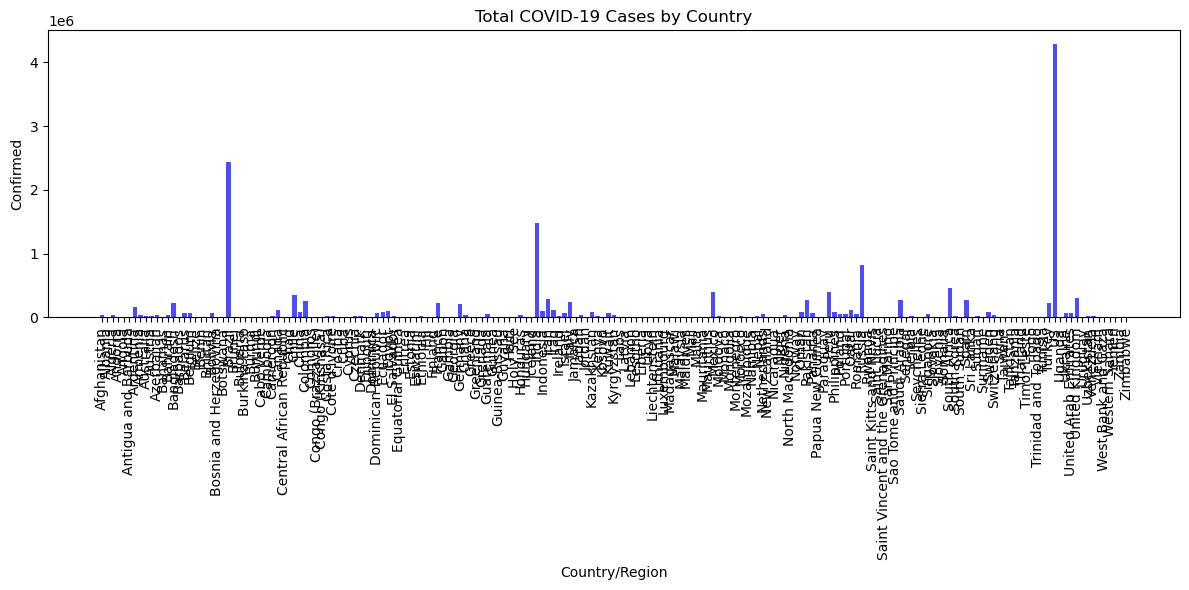

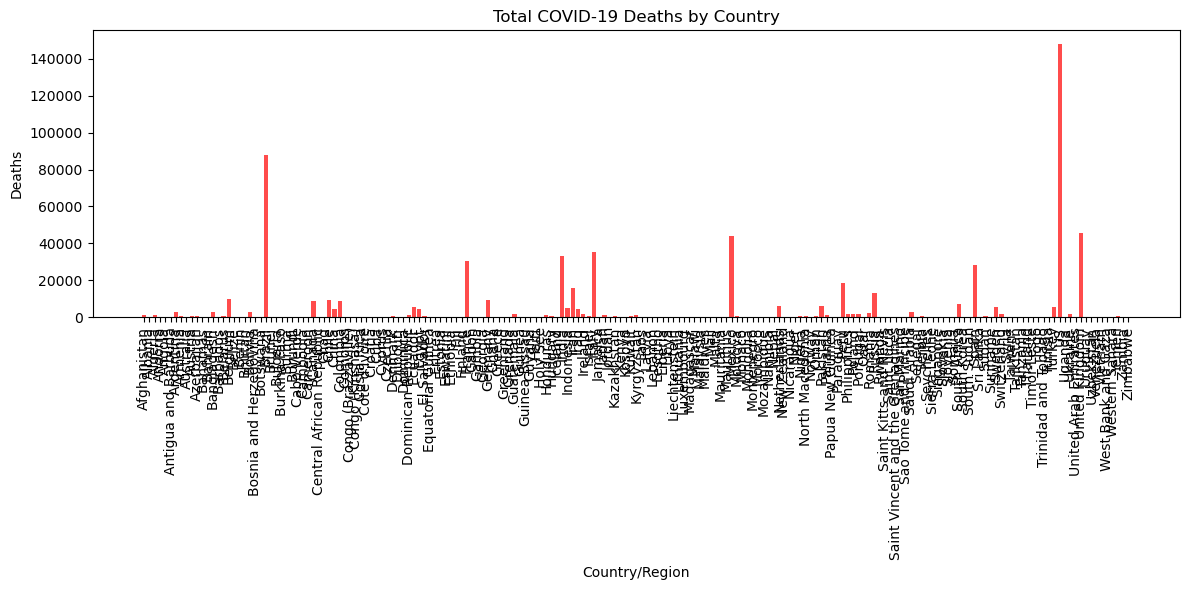

Countries with the highest total cases:
     Country/Region  Confirmed
173              US  4290259.0
23           Brazil  2442375.0
79            India  1480073.0
138          Russia   816680.0
154    South Africa   452529.0
111          Mexico   395489.0
132            Peru   389717.0
35            Chile   347923.0
177  United Kingdom   301708.0
81             Iran   293606.0
Countries with the highest total deaths:
     Country/Region    Deaths
173              US  148011.0
23           Brazil   87618.0
177  United Kingdom   45844.0
111          Mexico   44022.0
85            Italy   35112.0
79            India   33408.0
61           France   30212.0
157           Spain   28432.0
132            Peru   18418.0
81             Iran   15912.0


In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# Specify the full path to your CSV file
file_path = r'C:\Users\Shubhan\Downloads\country_wise_latest.csv'

# Load the data
try:
    df = pd.read_csv(file_path)
except PermissionError:
    print("Permission denied: Please check if the file is open in another program or if you have the necessary permissions.")
except FileNotFoundError:
    print("File not found: Please check if the file path is correct and the file exists.")
except Exception as e:
    print(f"An error occurred: {e}")

# Explore the data
print("DataFrame Shape:", df.shape)
print("DataFrame Columns:", df.columns)
print("Data Types:\n", df.dtypes)
print("Summary Statistics:\n", df.describe())
print("First 5 Rows:\n", df.head())

# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values[missing_values > 0])

# Data Cleaning: Impute missing values if necessary
# Only apply imputer to numeric columns
imputer = SimpleImputer(strategy='mean')  # You can choose different strategies
# Select only numeric columns for imputation
df[['Confirmed', 'Recovered', 'Deaths']] = imputer.fit_transform(df[['Confirmed', 'Recovered', 'Deaths']])

# Data Visualization
plt.figure(figsize=(12, 6))
plt.bar(df['Country/Region'], df['Confirmed'], color='blue', alpha=0.7)
plt.title('Total COVID-19 Cases by Country')
plt.xlabel('Country/Region')
plt.ylabel('Confirmed')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(df['Country/Region'], df['Deaths'], color='red', alpha=0.7)
plt.title('Total COVID-19 Deaths by Country')
plt.xlabel('Country/Region')
plt.ylabel('Deaths')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Insights
print("Countries with the highest total cases:")
print(df.nlargest(10, 'Confirmed')[['Country/Region', 'Confirmed']])

print("Countries with the highest total deaths:")
print(df.nlargest(10, 'Deaths')[['Country/Region', 'Deaths']])